# Final End-to-End EW Scheduler Prototype

This is the frozen deployment-style prototype.

For every HDF5 file in `./test_data`, the notebook:

1. converts raw STARE data to the same in-memory `T × 36` RF environment used by the project;
2. loads the frozen recursive belief updater;
3. loads the frozen Neural Thompson bandit ensemble;
4. runs the complete closed loop: **bandit → selected-band observation → recursive belief update → next action**;
5. computes the Oracle directly in memory on the same environment;
6. evaluates Random, Greedy-belief, Neural Thompson, and Oracle;
7. produces per-file and aggregate final metrics;
8. saves only final report/result files under `./final_results`.

No RF environments, Oracle schedules, trajectories, replay buffers, or model checkpoints are written.

In [1]:
from pathlib import Path
from collections import deque
import json
import random

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)

NumPy: 2.2.6
PyTorch: 2.3.1


In [2]:
# ============================================================
# 2. PATHS + FROZEN CONFIGURATION
# ============================================================

TEST_DATA_DIR = Path("./test_data")
TRAIN_FINAL_DIR = Path("./train_final")

RECURSIVE_MODEL_PATH = (
    TRAIN_FINAL_DIR / "recursive_belief_updater.pt"
)

BANDIT_CHECKPOINT_PATH = (
    TRAIN_FINAL_DIR / "neural_oracle_bandit.pt"
)

FINAL_RESULTS_DIR = Path("./final_results")
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Same RF representation used by generateRFEnvs.ipynb.
FREQ_MIN_MHZ = 0
FREQ_MAX_MHZ = 18_000
FREQ_BIN_MHZ = 500
TIME_BIN_S = 0.050

N_FREQ_BINS = int(
    (FREQ_MAX_MHZ - FREQ_MIN_MHZ)
    / FREQ_BIN_MHZ
)

FREQ_EDGES_MHZ = np.arange(
    FREQ_MIN_MHZ,
    FREQ_MAX_MHZ + FREQ_BIN_MHZ,
    FREQ_BIN_MHZ,
    dtype=np.float32
)

FREQ_CENTRES_MHZ = (
    FREQ_EDGES_MHZ[:-1]
    + FREQ_BIN_MHZ / 2
)

assert N_FREQ_BINS == 36

# Exact frozen Neural Bandit architecture.
SEQUENCE_LENGTH = 12
STATE_DIM = 7 * N_FREQ_BINS + 2
CANDIDATE_DIM = 7

GRU_HIDDEN_DIM = 128
ACTION_EMBED_DIM = 16
Q_HIDDEN_DIM = 128
N_BOOTSTRAP_HEADS = 5

INITIAL_SWEEP = True
MAX_SCAN_GAP_STEPS = 40
THOMPSON_MODE = "per_step"

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Test data:", TEST_DATA_DIR.resolve())
print("Recursive checkpoint:", RECURSIVE_MODEL_PATH.resolve())
print("Bandit checkpoint:", BANDIT_CHECKPOINT_PATH.resolve())
print("Final outputs:", FINAL_RESULTS_DIR.resolve())
print("Device:", DEVICE)
print("Bands:", N_FREQ_BINS)

Test data: C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\test_data
Recursive checkpoint: C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final\recursive_belief_updater.pt
Bandit checkpoint: C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\train_final\neural_oracle_bandit.pt
Final outputs: C:\Users\vacha\OneDrive\Desktop\Programming\Python\Hackathons\SIH2026 - EW\final_results
Device: cuda
Bands: 36


In [3]:
# ============================================================
# 3. DISCOVER TEST FILES
# ============================================================

test_files = sorted(
    TEST_DATA_DIR.glob("*.h5")
)

if not test_files:
    raise FileNotFoundError(
        f"No .h5 files found in {TEST_DATA_DIR.resolve()}"
    )

print(f"Found {len(test_files)} test HDF5 file(s).")

for path in test_files:
    print(" ", path.name)

Found 1 test HDF5 file(s).
  config_0.h5


In [4]:
# ============================================================
# 4. RAW HDF5 -> RF ENVIRONMENT, IN MEMORY ONLY
# ============================================================

def create_rf_environment(h5_path):
    # Same conversion used by generateRFEnvs.ipynb.

    with h5py.File(h5_path, "r") as f:
        data = f["data"][:]

        toa_us = data[:, 0]
        frequency_mhz = data[:, 1]

    toa_s = toa_us / 1_000_000.0

    max_time_s = np.max(toa_s)

    n_time_bins = int(
        np.ceil(max_time_s / TIME_BIN_S)
    )

    time_indices = np.floor(
        toa_s / TIME_BIN_S
    ).astype(np.int64)

    freq_indices = np.floor(
        frequency_mhz / FREQ_BIN_MHZ
    ).astype(np.int64)

    valid = (
        (time_indices >= 0)
        & (time_indices < n_time_bins)
        & (freq_indices >= 0)
        & (freq_indices < N_FREQ_BINS)
    )

    rf_env = np.zeros(
        (n_time_bins, N_FREQ_BINS),
        dtype=np.uint8
    )

    rf_env[
        time_indices[valid],
        freq_indices[valid]
    ] = 1

    return rf_env


test_environments = {}

for path in test_files:
    env = create_rf_environment(path)

    if env.ndim != 2 or env.shape[1] != N_FREQ_BINS:
        raise ValueError(
            f"{path.name}: produced {env.shape}; "
            f"expected (T, {N_FREQ_BINS})"
        )

    test_environments[path.name] = env

    print(
        f"{path.name:30s} "
        f"shape={str(env.shape):>12s} "
        f"active cells={int(env.sum()):6d}"
    )

config_0.h5                    shape=   (589, 36) active cells=   453


In [5]:
# ============================================================
# 5. LOAD FROZEN RECURSIVE BELIEF MODEL
# ============================================================

class BeliefUpdater(nn.Module):

    def __init__(
        self,
        n_bands=36,
        hidden_size=128
    ):
        super().__init__()

        self.n_bands = n_bands

        input_size = (
            n_bands
            + n_bands
            + 1
        )

        self.network = nn.Sequential(
            nn.Linear(
                input_size,
                hidden_size
            ),
            nn.ReLU(),

            nn.Linear(
                hidden_size,
                hidden_size
            ),
            nn.ReLU(),

            nn.Linear(
                hidden_size,
                n_bands
            )
        )

    def forward(
        self,
        probabilities,
        actions,
        observations
    ):

        action_one_hot = torch.zeros(
            actions.shape[0],
            self.n_bands,
            device=actions.device
        )

        action_one_hot.scatter_(
            1,
            actions.unsqueeze(1),
            1.0
        )

        observations = (
            observations.float()
            .unsqueeze(1)
        )

        x = torch.cat(
            [
                probabilities,
                action_one_hot,
                observations
            ],
            dim=1
        )

        return self.network(x)


recursive_checkpoint = torch.load(
    RECURSIVE_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

recursive_config = (
    recursive_checkpoint["model_config"]
)

recursive_model = BeliefUpdater(
    n_bands=recursive_config["n_freq_bins"],
    hidden_size=recursive_config["hidden_size"]
).to(DEVICE)

recursive_model.load_state_dict(
    recursive_checkpoint["model_state_dict"]
)

recursive_model.eval()

for parameter in recursive_model.parameters():
    parameter.requires_grad = False

P_baseline = np.asarray(
    recursive_checkpoint["P_baseline"],
    dtype=np.float32
)

assert P_baseline.shape == (N_FREQ_BINS,)

print("✓ Recursive model loaded.")
print("Hidden size:", recursive_config["hidden_size"])
print("Baseline shape:", P_baseline.shape)

✓ Recursive model loaded.
Hidden size: 128
Baseline shape: (36,)


In [6]:
# ============================================================
# 6. FROZEN RECURSIVE BELIEF PROVIDER
# ============================================================

class RecursiveBeliefProvider:

    def __init__(
        self,
        model,
        baseline,
        device
    ):
        self.model = model
        self.baseline = np.asarray(
            baseline,
            dtype=np.float32
        )
        self.device = device
        self.reset()

    def reset(self):

        self.belief = torch.tensor(
            self.baseline,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

    def step(
        self,
        action,
        observation
    ):

        action_tensor = torch.tensor(
            [action],
            dtype=torch.long,
            device=self.device
        )

        observation_tensor = torch.tensor(
            [observation],
            dtype=torch.float32,
            device=self.device
        )

        with torch.no_grad():

            logits = self.model(
                self.belief,
                action_tensor,
                observation_tensor
            )

            self.belief = torch.sigmoid(
                logits
            )

        return (
            self.belief
            .squeeze(0)
            .detach()
            .cpu()
            .numpy()
            .copy()
        )

In [7]:
# ============================================================
# 7. EXACT TRAINED SCHEDULER MEMORY + TEMPORAL BUILDER
# ============================================================

class SchedulerMemory:

    def __init__(
        self,
        n_bands=N_FREQ_BINS,
        hit_memory=10
    ):
        self.n_bands = n_bands
        self.hit_memory = hit_memory
        self.reset()

    def reset(self):

        self.scan_counts = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        self.hit_counts = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        self.age_since_scan = np.full(
            self.n_bands,
            np.inf,
            dtype=np.float32
        )

        self.time_since_hit = np.full(
            self.n_bands,
            np.inf,
            dtype=np.float32
        )

        self.last_observation = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        self.recent_observations = [
            deque(maxlen=self.hit_memory)
            for _ in range(self.n_bands)
        ]

        self.previous_action = -1
        self.step = 0

    def _normalized_age(self, values):

        values = np.asarray(
            values,
            dtype=np.float32
        )

        finite = np.isfinite(values)

        clipped = np.where(
            finite,
            np.minimum(
                values,
                float(MAX_SCAN_GAP_STEPS)
            ),
            float(MAX_SCAN_GAP_STEPS)
        )

        return (
            clipped
            / float(MAX_SCAN_GAP_STEPS)
        ).astype(np.float32)

    def hit_rates(self):

        rates = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        for band in range(self.n_bands):

            history = (
                self.recent_observations[band]
            )

            if history:
                rates[band] = (
                    float(sum(history))
                    / float(len(history))
                )

        return rates

    def state_vector(self, belief):

        belief = np.asarray(
            belief,
            dtype=np.float32
        )

        age = self._normalized_age(
            self.age_since_scan
        )

        time_since_hit = (
            self._normalized_age(
                self.time_since_hit
            )
        )

        hit_rates = self.hit_rates()

        scan_count = (
            np.log1p(self.scan_counts)
            / np.log1p(50.0)
        )

        scan_count = np.clip(
            scan_count,
            0.0,
            1.0
        )

        previous_action = np.zeros(
            self.n_bands,
            dtype=np.float32
        )

        if (
            0 <= self.previous_action
            < self.n_bands
        ):
            previous_action[
                self.previous_action
            ] = 1.0

        phase = (
            2.0
            * np.pi
            * self.step
            / 200.0
        )

        state = np.concatenate(
            [
                belief,
                age,
                hit_rates,
                time_since_hit,
                self.last_observation,
                scan_count,
                previous_action,
                [
                    np.sin(phase),
                    np.cos(phase)
                ],
            ]
        ).astype(np.float32)

        assert len(state) == STATE_DIM

        return state

    def candidate_features(self, belief):

        belief = np.asarray(
            belief,
            dtype=np.float32
        )

        age = self._normalized_age(
            self.age_since_scan
        )

        time_since_hit = (
            self._normalized_age(
                self.time_since_hit
            )
        )

        hit_rates = self.hit_rates()

        scan_count = (
            np.log1p(self.scan_counts)
            / np.log1p(50.0)
        )

        scan_count = np.clip(
            scan_count,
            0.0,
            1.0
        )

        band_position = (
            np.arange(
                self.n_bands,
                dtype=np.float32
            )
            / max(
                self.n_bands - 1,
                1
            )
        )

        features = np.stack(
            [
                belief,
                age,
                hit_rates,
                time_since_hit,
                self.last_observation,
                scan_count,
                band_position,
            ],
            axis=1
        ).astype(np.float32)

        assert features.shape == (
            self.n_bands,
            CANDIDATE_DIM
        )

        return features

    def update(
        self,
        action,
        observation
    ):

        hit = int(
            observation > 0
        )

        self.age_since_scan += 1

        finite_hit_age = np.isfinite(
            self.time_since_hit
        )

        self.time_since_hit[
            finite_hit_age
        ] += 1

        self.age_since_scan[
            action
        ] = 0

        self.scan_counts[
            action
        ] += 1

        self.hit_counts[
            action
        ] += hit

        self.last_observation[
            action
        ] = hit

        self.recent_observations[
            action
        ].append(hit)

        if hit:
            self.time_since_hit[
                action
            ] = 0

        self.previous_action = int(action)

        self.step += 1


class TemporalStateBuilder:

    def __init__(
        self,
        n_bands=N_FREQ_BINS,
        sequence_length=SEQUENCE_LENGTH
    ):
        self.n_bands = n_bands
        self.sequence_length = sequence_length

        self.memory = SchedulerMemory(
            n_bands=n_bands
        )

        self.history = deque(
            maxlen=sequence_length
        )

    def reset(self):

        self.memory.reset()
        self.history.clear()

    def observe_state(self, belief):

        state = self.memory.state_vector(
            belief
        )

        candidate = (
            self.memory.candidate_features(
                belief
            )
        )

        self.history.append(
            state.copy()
        )

        sequence = list(
            self.history
        )

        if len(sequence) < self.sequence_length:

            first = sequence[0]

            padding = [
                first.copy()
                for _ in range(
                    self.sequence_length
                    - len(sequence)
                )
            ]

            sequence = padding + sequence

        sequence = np.stack(
            sequence,
            axis=0
        ).astype(np.float32)

        assert sequence.shape == (
            self.sequence_length,
            STATE_DIM
        )

        return sequence, candidate

    def update(
        self,
        action,
        observation
    ):
        self.memory.update(
            action,
            observation
        )

In [8]:
# ============================================================
# 8. EXACT TRAINED NEURAL BANDIT HEADS
# ============================================================

class NeuralBanditHead(nn.Module):

    def __init__(
        self,
        state_dim=STATE_DIM,
        n_bands=N_FREQ_BINS,
        candidate_dim=CANDIDATE_DIM,
        gru_hidden_dim=GRU_HIDDEN_DIM,
        action_embed_dim=ACTION_EMBED_DIM,
        q_hidden_dim=Q_HIDDEN_DIM,
    ):
        super().__init__()

        self.n_bands = n_bands

        self.gru = nn.GRU(
            input_size=state_dim,
            hidden_size=gru_hidden_dim,
            batch_first=True
        )

        self.action_embedding = nn.Embedding(
            n_bands,
            action_embed_dim
        )

        self.q_network = nn.Sequential(
            nn.Linear(
                gru_hidden_dim
                + candidate_dim
                + action_embed_dim,
                q_hidden_dim
            ),

            nn.LayerNorm(
                q_hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                q_hidden_dim,
                q_hidden_dim // 2
            ),

            nn.ReLU(),

            nn.Linear(
                q_hidden_dim // 2,
                1
            )
        )

    def encode(self, state_sequence):

        _, hidden = self.gru(
            state_sequence
        )

        return hidden[-1]

    def forward(
        self,
        state_sequence,
        candidate_features
    ):

        latent = self.encode(
            state_sequence
        )

        batch_size = (
            state_sequence.shape[0]
        )

        latent = (
            latent
            .unsqueeze(1)
            .expand(
                -1,
                self.n_bands,
                -1
            )
        )

        band_ids = torch.arange(
            self.n_bands,
            device=state_sequence.device
        )

        band_embeddings = (
            self.action_embedding(
                band_ids
            )
        )

        band_embeddings = (
            band_embeddings
            .unsqueeze(0)
            .expand(
                batch_size,
                -1,
                -1
            )
        )

        x = torch.cat(
            [
                latent,
                candidate_features,
                band_embeddings
            ],
            dim=-1
        )

        return self.q_network(
            x
        ).squeeze(-1)


bandit_checkpoint = torch.load(
    BANDIT_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

architecture = (
    bandit_checkpoint["architecture"]
)

for key, expected in [
    ("n_bands", N_FREQ_BINS),
    ("state_dim", STATE_DIM),
    ("candidate_dim", CANDIDATE_DIM),
    ("sequence_length", SEQUENCE_LENGTH),
    ("gru_hidden_dim", GRU_HIDDEN_DIM),
    ("action_embed_dim", ACTION_EMBED_DIM),
    ("q_hidden_dim", Q_HIDDEN_DIM),
    ("n_heads", N_BOOTSTRAP_HEADS),
]:

    assert architecture[key] == expected, (
        f"Checkpoint mismatch for {key}: "
        f"{architecture[key]} != {expected}"
    )

bandit_heads = []

for state_dict in (
    bandit_checkpoint["model_state_dict"]
):

    head = NeuralBanditHead().to(DEVICE)

    head.load_state_dict(
        state_dict
    )

    head.eval()

    for parameter in head.parameters():
        parameter.requires_grad = False

    bandit_heads.append(head)

print(
    f"✓ Loaded {len(bandit_heads)} frozen bootstrap heads."
)

print(
    "Checkpoint episode:",
    bandit_checkpoint["episode_index"]
)

✓ Loaded 5 frozen bootstrap heads.
Checkpoint episode: 5


In [9]:
# ============================================================
# 9. FROZEN NEURAL THOMPSON POLICY
# ============================================================

class FrozenNeuralThompsonPolicy:

    def __init__(self):

        self.state_builder = (
            TemporalStateBuilder()
        )

        self.rng = np.random.default_rng(
            SEED
        )

        self.selected_episode_head = None

    def reset(self):

        self.state_builder.reset()
        self.selected_episode_head = None

    def select_action(self, belief):

        sequence, candidate_features = (
            self.state_builder.observe_state(
                belief
            )
        )

        step = (
            self.state_builder
            .memory
            .step
        )

        # Same initial sweep as training.
        if (
            INITIAL_SWEEP
            and step < N_FREQ_BINS
        ):

            return int(step)

        ages = (
            self.state_builder
            .memory
            .age_since_scan
        )

        stale_mask = (
            ~np.isfinite(ages)
            |
            (
                ages
                >= MAX_SCAN_GAP_STEPS
            )
        )

        if np.any(stale_mask):
            allowed = stale_mask
        else:
            allowed = np.ones(
                N_FREQ_BINS,
                dtype=bool
            )

        if THOMPSON_MODE == "per_episode":

            if self.selected_episode_head is None:

                self.selected_episode_head = int(
                    self.rng.integers(
                        0,
                        len(bandit_heads)
                    )
                )

            head_index = (
                self.selected_episode_head
            )

        else:

            head_index = int(
                self.rng.integers(
                    0,
                    len(bandit_heads)
                )
            )

        state_tensor = torch.tensor(
            sequence,
            dtype=torch.float32,
            device=DEVICE
        ).unsqueeze(0)

        candidate_tensor = torch.tensor(
            candidate_features,
            dtype=torch.float32,
            device=DEVICE
        ).unsqueeze(0)

        with torch.no_grad():

            q_values = (
                bandit_heads[head_index](
                    state_tensor,
                    candidate_tensor
                )[0]
                .detach()
                .cpu()
                .numpy()
            )

        q_values = q_values.copy()

        q_values[
            ~allowed
        ] = -np.inf

        return int(
            np.argmax(q_values)
        )

    def update(
        self,
        action,
        observation
    ):

        self.state_builder.update(
            action,
            observation
        )

In [10]:
# ============================================================
# 10. EVENT EXTRACTION
# ============================================================

def extract_transmission_events(env):

    env = np.asarray(env)

    if env.ndim != 2:
        raise ValueError(
            f"Expected 2-D environment, got {env.shape}"
        )

    events = []
    event_id = 0

    for band in range(N_FREQ_BINS):

        in_event = False
        start = None

        for t in range(len(env)):

            active = bool(
                env[t, band] > 0
            )

            if active and not in_event:

                start = t
                in_event = True

            elif not active and in_event:

                end = t - 1

                events.append({
                    "id": event_id,
                    "band": band,
                    "start": start,
                    "end": end,
                    "duration": end - start + 1
                })

                event_id += 1
                in_event = False

        if in_event:

            end = len(env) - 1

            events.append({
                "id": event_id,
                "band": band,
                "start": start,
                "end": end,
                "duration": end - start + 1
            })

            event_id += 1

    events.sort(
        key=lambda e: (e["start"], e["band"])
    )

    for new_id, event in enumerate(events):
        event["id"] = new_id

    return events


def build_event_lookup(
    events,
    n_time_steps
):

    active_events = [
        [] for _ in range(n_time_steps)
    ]

    for event in events:

        for t in range(
            event["start"],
            event["end"] + 1
        ):

            active_events[t].append(
                event["id"]
            )

    return active_events

In [11]:
# ============================================================
# 11. GENERIC CLOSED-LOOP POLICY RUNNER
# ============================================================

class RandomScanPolicy:

    def __init__(self, seed=123):
        self.rng = np.random.default_rng(seed)

    def reset(self):
        pass

    def select_action(self, belief):
        return int(
            self.rng.integers(
                0,
                N_FREQ_BINS
            )
        )

    def update(self, action, observation):
        pass


class GreedyBeliefPolicy:

    def reset(self):
        pass

    def select_action(self, belief):
        return int(
            np.argmax(
                np.asarray(belief)
            )
        )

    def update(self, action, observation):
        pass


def run_policy(
    env,
    policy
):

    env = np.asarray(
        env,
        dtype=np.float32
    )

    events = extract_transmission_events(
        env
    )

    active_events = build_event_lookup(
        events,
        len(env)
    )

    event_by_id = {
        event["id"]: event
        for event in events
    }

    policy.reset()

    belief_provider = RecursiveBeliefProvider(
        recursive_model,
        P_baseline,
        DEVICE
    )

    belief_provider.reset()

    intercepted_event_ids = set()
    interception_times = {}

    actions = []
    observations = []
    beliefs = []

    belief = (
        belief_provider(
            action=None,
            observation=None
        )
        if hasattr(belief_provider, "__call__")
        else belief_provider.belief.squeeze(0).detach().cpu().numpy().copy()
    )

    # The provider intentionally exposes reset + step.
    if not isinstance(belief, np.ndarray):
        belief = (
            belief_provider.belief
            .squeeze(0)
            .detach()
            .cpu()
            .numpy()
            .copy()
        )

    for t in range(len(env)):

        action = int(
            policy.select_action(
                belief
            )
        )

        if not (
            0 <= action < N_FREQ_BINS
        ):
            raise ValueError(
                f"Invalid action {action}"
            )

        observation = float(
            env[t, action]
        )

        next_belief = (
            belief_provider.step(
                action,
                observation
            )
        )

        actions.append(action)
        observations.append(observation)
        beliefs.append(
            np.asarray(
                belief,
                dtype=np.float32
            ).copy()
        )

        # Offline evaluation only.
        for event_id in active_events[t]:

            if event_id in intercepted_event_ids:
                continue

            event = event_by_id[event_id]

            if event["band"] == action:

                intercepted_event_ids.add(
                    event_id
                )

                interception_times[
                    event_id
                ] = t

        policy.update(
            action,
            observation
        )

        belief = next_belief

    intercepted_events = []

    for event_id in sorted(
        intercepted_event_ids
    ):

        event = event_by_id[event_id]

        t = interception_times[event_id]

        delay_steps = (
            t - event["start"]
        )

        intercepted_events.append({
            **event,
            "interception_time": t,
            "delay_steps": delay_steps,
            "delay_s": (
                delay_steps
                * TIME_BIN_S
            )
        })

    missed_events = [
        event
        for event in events
        if event["id"]
        not in intercepted_event_ids
    ]

    delays = [
        x["delay_s"]
        for x in intercepted_events
    ]

    return {
        "actions": np.asarray(
            actions,
            dtype=np.int64
        ),
        "observations": np.asarray(
            observations,
            dtype=np.float32
        ),
        "beliefs": np.asarray(
            beliefs,
            dtype=np.float32
        ),
        "events": events,
        "intercepted_events": intercepted_events,
        "missed_events": missed_events,
        "total_event_count": len(events),
        "intercepted_event_count": len(
            intercepted_events
        ),
        "event_interception_rate": (
            len(intercepted_events)
            / len(events)
            if events
            else np.nan
        ),
        "mean_intercept_delay_s": (
            float(np.mean(delays))
            if delays
            else np.nan
        ),
        "median_intercept_delay_s": (
            float(np.median(delays))
            if delays
            else np.nan
        ),
        "max_intercept_delay_s": (
            float(np.max(delays))
            if delays
            else np.nan
        ),
        "total_intercept_delay_s": (
            float(np.sum(delays))
            if delays
            else 0.0
        ),
        "unique_bands_found": len({
            x["band"]
            for x in intercepted_events
        }),
    }

In [12]:
# ============================================================
# 12. BELIEF PROVIDER INITIAL STATE HELPER
# ============================================================

def initial_belief(provider):
    return (
        provider.belief
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
        .copy()
    )

In [13]:
# ============================================================
# 13. IN-MEMORY ORACLE
# ============================================================

class Edge:

    def __init__(
        self,
        to,
        rev,
        capacity,
        cost
    ):
        self.to = to
        self.rev = rev
        self.capacity = capacity
        self.cost = cost


class MinCostMaxFlow:

    def __init__(self, n):

        self.n = n
        self.graph = [
            [] for _ in range(n)
        ]

    def add_edge(
        self,
        u,
        v,
        capacity,
        cost
    ):

        forward = Edge(
            to=v,
            rev=len(self.graph[v]),
            capacity=capacity,
            cost=cost
        )

        backward = Edge(
            to=u,
            rev=len(self.graph[u]),
            capacity=0,
            cost=-cost
        )

        self.graph[u].append(
            forward
        )

        self.graph[v].append(
            backward
        )

    def min_cost_flow(
        self,
        source,
        sink
    ):

        flow = 0
        total_cost = 0

        while True:

            dist = [
                float("inf")
            ] * self.n

            prev_node = [
                -1
            ] * self.n

            prev_edge = [
                -1
            ] * self.n

            dist[source] = 0

            updated = True

            for _ in range(self.n - 1):

                if not updated:
                    break

                updated = False

                for u in range(self.n):

                    if dist[u] == float("inf"):
                        continue

                    for edge_index, edge in enumerate(
                        self.graph[u]
                    ):

                        if edge.capacity <= 0:
                            continue

                        new_dist = (
                            dist[u]
                            + edge.cost
                        )

                        if new_dist < dist[edge.to]:

                            dist[edge.to] = new_dist
                            prev_node[edge.to] = u
                            prev_edge[edge.to] = edge_index
                            updated = True

            if dist[sink] == float("inf"):
                break

            node = sink

            while node != source:

                u = prev_node[node]
                edge_index = prev_edge[node]

                edge = self.graph[u][edge_index]

                edge.capacity -= 1

                reverse = self.graph[
                    node
                ][edge.rev]

                reverse.capacity += 1

                node = u

            flow += 1
            total_cost += dist[sink]

        return flow, total_cost


def solve_oracle(env):

    env = np.asarray(
        env,
        dtype=np.float32
    )

    n_time_steps = len(env)

    events = extract_transmission_events(
        env
    )

    if not events:

        return {
            "events": [],
            "schedule": np.full(
                n_time_steps,
                -1,
                dtype=np.int64
            ),
            "intercepted_events": [],
            "missed_events": [],
            "max_intercepted_events": 0,
            "total_delay_steps": 0,
            "total_delay_s": 0.0
        }

    n_events = len(events)

    source = 0
    event_offset = 1
    time_offset = (
        event_offset
        + n_events
    )
    sink = (
        time_offset
        + n_time_steps
    )

    solver = MinCostMaxFlow(
        sink + 1
    )

    for i, event in enumerate(events):

        event_node = (
            event_offset + i
        )

        solver.add_edge(
            source,
            event_node,
            1,
            0
        )

        for t in range(
            event["start"],
            event["end"] + 1
        ):

            time_node = (
                time_offset + t
            )

            solver.add_edge(
                event_node,
                time_node,
                1,
                t - event["start"]
            )

    for t in range(n_time_steps):

        solver.add_edge(
            time_offset + t,
            sink,
            1,
            0
        )

    max_intercepted, total_delay_steps = (
        solver.min_cost_flow(
            source,
            sink
        )
    )

    event_interception_time = {}

    for i, event in enumerate(events):

        event_node = (
            event_offset + i
        )

        for edge in solver.graph[event_node]:

            if (
                time_offset
                <= edge.to
                < time_offset + n_time_steps
                and edge.capacity == 0
            ):

                event_interception_time[
                    event["id"]
                ] = (
                    edge.to - time_offset
                )

                break

    schedule = np.full(
        n_time_steps,
        -1,
        dtype=np.int64
    )

    intercepted_events = []

    for event in events:

        event_id = event["id"]

        if event_id not in event_interception_time:
            continue

        t = event_interception_time[
            event_id
        ]

        schedule[t] = event["band"]

        delay_steps = (
            t - event["start"]
        )

        intercepted_events.append({
            **event,
            "interception_time": t,
            "delay_steps": delay_steps,
            "delay_s": (
                delay_steps
                * TIME_BIN_S
            )
        })

    intercepted_ids = {
        x["id"]
        for x in intercepted_events
    }

    missed_events = [
        event
        for event in events
        if event["id"]
        not in intercepted_ids
    ]

    return {
        "events": events,
        "schedule": schedule,
        "intercepted_events": intercepted_events,
        "missed_events": missed_events,
        "max_intercepted_events": max_intercepted,
        "total_delay_steps": total_delay_steps,
        "total_delay_s": (
            total_delay_steps
            * TIME_BIN_S
        )
    }


def verify_oracle(env, oracle_result):

    schedule = oracle_result["schedule"]

    assert len(schedule) == len(env)

    assert np.all(
        (schedule == -1)
        | (
            (schedule >= 0)
            & (schedule < N_FREQ_BINS)
        )
    )

    for t, band in enumerate(schedule):

        if band == -1:
            continue

        assert env[t, band] > 0

    assert (
        np.sum(schedule >= 0)
        == len(
            oracle_result["intercepted_events"]
        )
    )

    return True

In [14]:
# ============================================================
# 14. RUN THE ENTIRE FROZEN PIPELINE
# ============================================================

all_results = []

for file_index, (name, env) in enumerate(
    test_environments.items(),
    start=1
):

    print("\n" + "=" * 80)
    print(
        f"TEST FILE {file_index}/{len(test_environments)}: {name}"
    )
    print(
        f"Environment: {env.shape[0]} time steps × "
        f"{env.shape[1]} bands"
    )
    print("=" * 80)

    # Neural
    neural_result = run_policy(
        env,
        FrozenNeuralThompsonPolicy()
    )

    # Baselines
    random_result = run_policy(
        env,
        RandomScanPolicy(seed=SEED)
    )

    greedy_result = run_policy(
        env,
        GreedyBeliefPolicy()
    )

    # Oracle is computed independently and entirely in memory.
    oracle_result = solve_oracle(env)

    verify_oracle(
        env,
        oracle_result
    )

    # Information-boundary sanity checks.
    for label, result in [
        ("Neural", neural_result),
        ("Random", random_result),
        ("Greedy", greedy_result)
    ]:

        assert len(result["actions"]) == len(env)
        assert len(result["observations"]) == len(env)
        assert len(result["beliefs"]) == len(env)

        assert np.all(
            np.isfinite(result["beliefs"])
        )

        assert np.all(
            (result["beliefs"] >= 0)
            & (result["beliefs"] <= 1)
        )

    total_events = len(
        neural_result["events"]
    )

    oracle_intercepted = len(
        oracle_result["intercepted_events"]
    )

    def event_map(result):
        return {
            x["id"]: x
            for x in result["intercepted_events"]
        }

    neural_events = event_map(neural_result)
    random_events = event_map(random_result)
    greedy_events = event_map(greedy_result)
    oracle_events = event_map(oracle_result)

    def common_delay(policy_events, oracle_events):

        common = (
            set(policy_events)
            & set(oracle_events)
        )

        if not common:
            return np.nan, np.nan, np.nan

        policy_delay = float(
            np.mean([
                policy_events[i]["delay_s"]
                for i in common
            ])
        )

        oracle_delay = float(
            np.mean([
                oracle_events[i]["delay_s"]
                for i in common
            ])
        )

        return (
            policy_delay,
            oracle_delay,
            policy_delay - oracle_delay
        )

    neural_common, oracle_common_neural, neural_excess = (
        common_delay(
            neural_events,
            oracle_events
        )
    )

    random_common, oracle_common_random, random_excess = (
        common_delay(
            random_events,
            oracle_events
        )
    )

    greedy_common, oracle_common_greedy, greedy_excess = (
        common_delay(
            greedy_events,
            oracle_events
        )
    )

    def oracle_mean_delay():

        delays = [
            x["delay_s"]
            for x in oracle_result[
                "intercepted_events"
            ]
        ]

        return (
            float(np.mean(delays))
            if delays
            else np.nan
        )

    row = {
        "file": name,
        "time_steps": len(env),
        "duration_s": len(env) * TIME_BIN_S,
        "active_cells": int(env.sum()),
        "total_events": total_events,

        "random_intercepted":
            random_result["intercepted_event_count"],
        "random_isr":
            random_result["event_interception_rate"],
        "random_mean_delay_s":
            random_result["mean_intercept_delay_s"],
        "random_unique_bands":
            random_result["unique_bands_found"],

        "greedy_intercepted":
            greedy_result["intercepted_event_count"],
        "greedy_isr":
            greedy_result["event_interception_rate"],
        "greedy_mean_delay_s":
            greedy_result["mean_intercept_delay_s"],
        "greedy_unique_bands":
            greedy_result["unique_bands_found"],

        "neural_intercepted":
            neural_result["intercepted_event_count"],
        "neural_isr":
            neural_result["event_interception_rate"],
        "neural_mean_delay_s":
            neural_result["mean_intercept_delay_s"],
        "neural_median_delay_s":
            neural_result["median_intercept_delay_s"],
        "neural_max_delay_s":
            neural_result["max_intercept_delay_s"],
        "neural_unique_bands_hit":
            neural_result["unique_bands_found"],
        "neural_unique_bands_scanned":
            int(np.unique(
                neural_result["actions"]
            ).size),
        "neural_scan_hit_rate":
            float(
                neural_result["observations"].mean()
            ),

        "oracle_intercepted":
            oracle_intercepted,
        "oracle_isr":
            (
                oracle_intercepted / total_events
                if total_events > 0
                else np.nan
            ),
        "oracle_mean_delay_s":
            oracle_mean_delay(),
        "oracle_schedule_scans":
            int(
                np.sum(
                    oracle_result["schedule"] >= 0
                )
            ),

        "neural_vs_oracle_capture":
            (
                neural_result[
                    "intercepted_event_count"
                ]
                / oracle_intercepted
                if oracle_intercepted > 0
                else np.nan
            ),

        "neural_common_events_with_oracle":
            len(
                set(neural_events)
                & set(oracle_events)
            ),

        "neural_common_delay_s":
            neural_common,

        "oracle_delay_on_neural_common_s":
            oracle_common_neural,

        "neural_common_excess_delay_s":
            neural_excess,

        "random_vs_oracle_capture":
            (
                random_result[
                    "intercepted_event_count"
                ]
                / oracle_intercepted
                if oracle_intercepted > 0
                else np.nan
            ),

        "greedy_vs_oracle_capture":
            (
                greedy_result[
                    "intercepted_event_count"
                ]
                / oracle_intercepted
                if oracle_intercepted > 0
                else np.nan
            ),

        "random_common_excess_delay_s":
            random_excess,

        "greedy_common_excess_delay_s":
            greedy_excess,
    }

    all_results.append(row)

    print(
        f"Random          ISR: {row['random_isr']:.2%}"
    )
    print(
        f"Greedy belief   ISR: {row['greedy_isr']:.2%}"
    )
    print(
        f"Neural Thompson ISR: {row['neural_isr']:.2%}"
    )
    print(
        f"Oracle          ISR: {row['oracle_isr']:.2%}"
    )
    print(
        f"Neural / Oracle    : "
        f"{row['neural_vs_oracle_capture']:.2%}"
    )
    print(
        f"Neural mean delay : "
        f"{row['neural_mean_delay_s']:.4f} s"
    )
    print(
        f"Oracle mean delay : "
        f"{row['oracle_mean_delay_s']:.4f} s"
    )


TEST FILE 1/1: config_0.h5
Environment: 589 time steps × 36 bands
Random          ISR: 33.33%
Greedy belief   ISR: 16.67%
Neural Thompson ISR: 41.67%
Oracle          ISR: 100.00%
Neural / Oracle    : 41.67%
Neural mean delay : 0.8000 s
Oracle mean delay : 0.0063 s


In [15]:
# ============================================================
# 15. AGGREGATE FINAL METRICS
# ============================================================

results_df = pd.DataFrame(
    all_results
)

total_events = int(
    results_df["total_events"].sum()
)

def total_intercepted(column):
    return int(
        results_df[column].sum()
    )

def micro_isr(column):
    count = total_intercepted(column)
    return (
        count / total_events
        if total_events > 0
        else np.nan
    )

def weighted_delay(
    delay_column,
    count_column
):

    count = int(
        results_df[count_column].sum()
    )

    if count == 0:
        return np.nan

    weighted = float(
        results_df[
            delay_column
        ].fillna(0)
        .mul(
            results_df[
                count_column
            ]
        )
        .sum()
    )

    return weighted / count


aggregate = {
    "test_files": len(results_df),
    "total_time_steps": int(
        results_df["time_steps"].sum()
    ),
    "total_duration_s": float(
        results_df["duration_s"].sum()
    ),
    "total_events": total_events,

    "random_intercepted":
        total_intercepted("random_intercepted"),
    "random_micro_isr":
        micro_isr("random_intercepted"),
    "random_mean_delay_s":
        weighted_delay(
            "random_mean_delay_s",
            "random_intercepted"
        ),

    "greedy_intercepted":
        total_intercepted("greedy_intercepted"),
    "greedy_micro_isr":
        micro_isr("greedy_intercepted"),
    "greedy_mean_delay_s":
        weighted_delay(
            "greedy_mean_delay_s",
            "greedy_intercepted"
        ),

    "neural_intercepted":
        total_intercepted("neural_intercepted"),
    "neural_micro_isr":
        micro_isr("neural_intercepted"),
    "neural_mean_delay_s":
        weighted_delay(
            "neural_mean_delay_s",
            "neural_intercepted"
        ),

    "oracle_intercepted":
        total_intercepted("oracle_intercepted"),
    "oracle_micro_isr":
        micro_isr("oracle_intercepted"),
    "oracle_mean_delay_s":
        weighted_delay(
            "oracle_mean_delay_s",
            "oracle_intercepted"
        ),
}

aggregate["neural_vs_random_relative_gain"] = (
    aggregate["neural_micro_isr"]
    / aggregate["random_micro_isr"]
    - 1.0
    if aggregate["random_micro_isr"] > 0
    else np.nan
)

aggregate["neural_vs_oracle_capture"] = (
    aggregate["neural_intercepted"]
    / aggregate["oracle_intercepted"]
    if aggregate["oracle_intercepted"] > 0
    else np.nan
)

aggregate["neural_event_gap_to_oracle"] = (
    aggregate["oracle_intercepted"]
    - aggregate["neural_intercepted"]
)

aggregate["mean_neural_unique_bands_scanned"] = (
    float(
        results_df[
            "neural_unique_bands_scanned"
        ].mean()
    )
)

aggregate["mean_neural_scan_hit_rate"] = (
    float(
        results_df[
            "neural_scan_hit_rate"
        ].mean()
    )
)

print("=" * 80)
print("FINAL END-TO-END PROTOTYPE RESULTS")
print("=" * 80)

print(
    f"Test files             : {aggregate['test_files']}"
)

print(
    f"Transmission events    : {aggregate['total_events']}"
)

print(
    f"Random ISR             : "
    f"{aggregate['random_micro_isr']:.2%}"
)

print(
    f"Greedy belief ISR      : "
    f"{aggregate['greedy_micro_isr']:.2%}"
)

print(
    f"Neural Thompson ISR    : "
    f"{aggregate['neural_micro_isr']:.2%}"
)

print(
    f"Oracle ISR             : "
    f"{aggregate['oracle_micro_isr']:.2%}"
)

print(
    f"Neural vs Random gain  : "
    f"{aggregate['neural_vs_random_relative_gain']:.2%}"
)

print(
    f"Neural / Oracle        : "
    f"{aggregate['neural_vs_oracle_capture']:.2%}"
)

print(
    f"Neural mean delay      : "
    f"{aggregate['neural_mean_delay_s']:.4f} s"
)

print(
    f"Oracle mean delay      : "
    f"{aggregate['oracle_mean_delay_s']:.4f} s"
)

FINAL END-TO-END PROTOTYPE RESULTS
Test files             : 1
Transmission events    : 24
Random ISR             : 33.33%
Greedy belief ISR      : 16.67%
Neural Thompson ISR    : 41.67%
Oracle ISR             : 100.00%
Neural vs Random gain  : 25.00%
Neural / Oracle        : 41.67%
Neural mean delay      : 0.8000 s
Oracle mean delay      : 0.0063 s


In [16]:
# ============================================================
# 17. ADDITIONAL FINAL DIAGNOSTICS
# ============================================================

diagnostic_rows = []

for _, row in results_df.iterrows():

    env_name = row["file"]

    # Re-run nothing: all policy trajectories are already
    # available only transiently inside this evaluation cell.
    # For final aggregate diagnostics, use the saved scalar
    # results plus event-level counts.

    diagnostic_rows.append({
        "file": env_name,
        "neural_unique_bands_scanned":
            row["neural_unique_bands_scanned"],
        "neural_unique_bands_hit":
            row["neural_unique_bands_hit"],
        "neural_scan_hit_rate":
            row["neural_scan_hit_rate"],
        "neural_scan_coverage":
            row["neural_unique_bands_scanned"]
            / N_FREQ_BINS,
        "neural_oracle_capture":
            row["neural_vs_oracle_capture"],
        "neural_common_events":
            row["neural_common_events_with_oracle"],
        "neural_common_excess_delay_s":
            row["neural_common_excess_delay_s"],
    })

diagnostics_df = pd.DataFrame(
    diagnostic_rows
)

print("=" * 80)
print("ADDITIONAL FINAL DIAGNOSTICS")
print("=" * 80)

print(
    "Mean Neural scan hit rate:",
    f"{diagnostics_df['neural_scan_hit_rate'].mean():.2%}"
)

print(
    "Mean Neural band coverage:",
    f"{diagnostics_df['neural_scan_coverage'].mean():.2%}"
)

print(
    "Mean unique bands scanned:",
    f"{diagnostics_df['neural_unique_bands_scanned'].mean():.2f}"
)

print(
    "Mean unique bands producing hits:",
    f"{diagnostics_df['neural_unique_bands_hit'].mean():.2f}"
)

print(
    "Neural events captured that Oracle also captured:",
    int(
        diagnostics_df[
            "neural_common_events"
        ].sum()
    )
)

finite_excess = diagnostics_df[
    "neural_common_excess_delay_s"
].dropna()

if len(finite_excess):
    print(
        "Mean excess delay on common events:",
        f"{finite_excess.mean():.4f} s"
    )

print()
print("Per-file diagnostics:")
display(diagnostics_df)

ADDITIONAL FINAL DIAGNOSTICS
Mean Neural scan hit rate: 2.21%
Mean Neural band coverage: 100.00%
Mean unique bands scanned: 36.00
Mean unique bands producing hits: 2.00
Neural events captured that Oracle also captured: 10
Mean excess delay on common events: 0.7950 s

Per-file diagnostics:


,file,neural_unique_bands_scanned,neural_unique_bands_hit,neural_scan_hit_rate,neural_scan_coverage,neural_oracle_capture,neural_common_events,neural_common_excess_delay_s
0,config_0.h5,36,2,0.022071,1.0,0.416667,10,0.795


In [17]:
# ============================================================
# 18. EVENT-LEVEL PERFORMANCE BY EVENT DURATION
# ============================================================

# Reconstruct event-duration groups directly from the in-memory
# test environments and compare Neural vs Oracle interception.

duration_rows = []

for name, env in test_environments.items():

    events = extract_transmission_events(env)

    neural_policy = FrozenNeuralThompsonPolicy()
    neural_result = run_policy(
        env,
        neural_policy
    )

    neural_ids = {
        x["id"]
        for x in neural_result[
            "intercepted_events"
        ]
    }

    oracle_result = solve_oracle(env)

    oracle_ids = {
        x["id"]
        for x in oracle_result[
            "intercepted_events"
        ]
    }

    for event in events:

        if event["duration"] <= 1:
            duration_group = "1 step"
        elif event["duration"] <= 2:
            duration_group = "2 steps"
        elif event["duration"] <= 4:
            duration_group = "3-4 steps"
        else:
            duration_group = "5+ steps"

        duration_rows.append({
            "file": name,
            "duration_steps": event["duration"],
            "duration_group": duration_group,
            "neural_intercepted":
                event["id"] in neural_ids,
            "oracle_intercepted":
                event["id"] in oracle_ids,
        })

duration_df = pd.DataFrame(
    duration_rows
)

duration_summary = (
    duration_df
    .groupby("duration_group", sort=False)
    .agg(
        events=("duration_steps", "size"),
        neural_intercepted=("neural_intercepted", "sum"),
        oracle_intercepted=("oracle_intercepted", "sum"),
    )
)

duration_summary["neural_isr"] = (
    duration_summary["neural_intercepted"]
    / duration_summary["events"]
)

duration_summary["oracle_isr"] = (
    duration_summary["oracle_intercepted"]
    / duration_summary["events"]
)

print("=" * 80)
print("EVENT-DURATION BREAKDOWN")
print("=" * 80)

display(
    duration_summary
)

EVENT-DURATION BREAKDOWN


,events,neural_intercepted,oracle_intercepted,neural_isr,oracle_isr
duration_group,,,,,
5+ steps,14,10,14,0.714286,1.0
3-4 steps,5,0,5,0.000000,1.0
2 steps,4,0,4,0.000000,1.0
1 step,1,0,1,0.000000,1.0


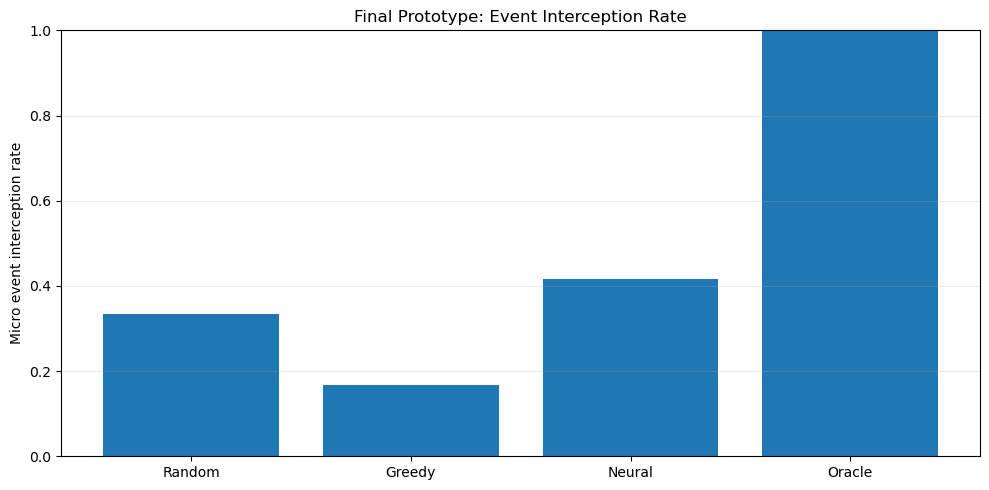

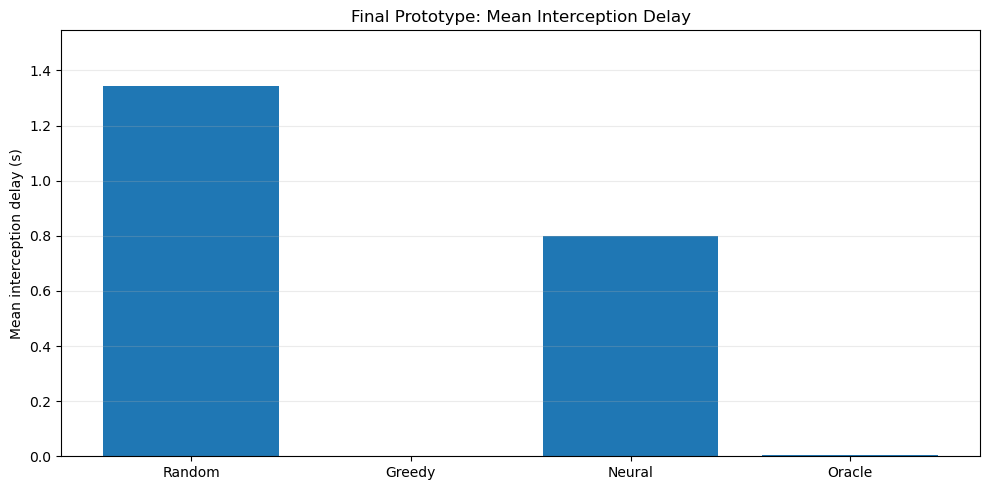

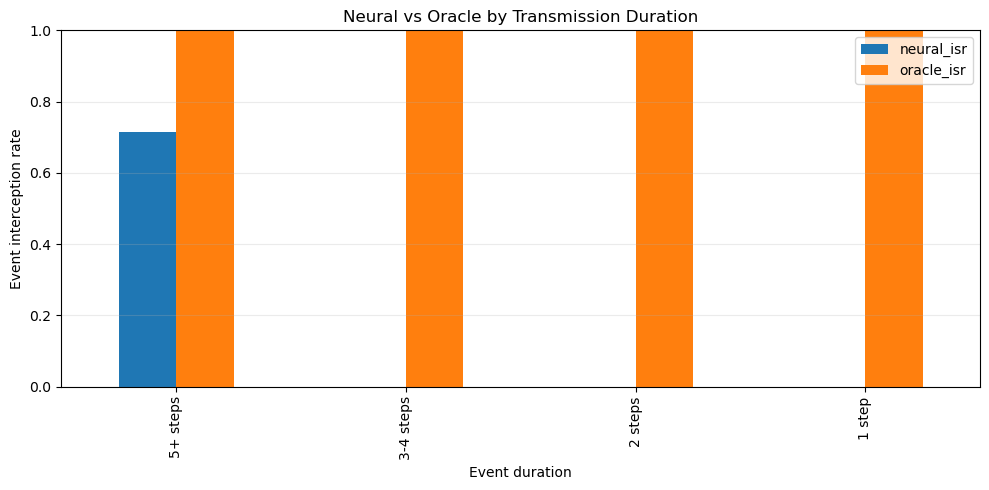

In [18]:
# ============================================================
# 19. FINAL REPORT PLOTS
# ============================================================

# ---- ISR ----
labels = [
    "Random",
    "Greedy",
    "Neural",
    "Oracle",
]

isr_values = [
    aggregate["random_micro_isr"],
    aggregate["greedy_micro_isr"],
    aggregate["neural_micro_isr"],
    aggregate["oracle_micro_isr"],
]

plt.figure(figsize=(10, 5))
plt.bar(labels, isr_values)
plt.ylabel("Micro event interception rate")
plt.title("Final Prototype: Event Interception Rate")
plt.ylim(
    0,
    min(
        1.0,
        max(isr_values) * 1.15
    )
)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

isr_plot_path = (
    FINAL_RESULTS_DIR
    / "final_isr_comparison.png"
)

plt.savefig(
    isr_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ---- Delay ----
delay_values = [
    aggregate["random_mean_delay_s"],
    aggregate["greedy_mean_delay_s"],
    aggregate["neural_mean_delay_s"],
    aggregate["oracle_mean_delay_s"],
]

plt.figure(figsize=(10, 5))
plt.bar(labels, delay_values)
plt.ylabel("Mean interception delay (s)")
plt.title("Final Prototype: Mean Interception Delay")

finite_values = [
    x for x in delay_values
    if np.isfinite(x)
]

if finite_values:
    plt.ylim(
        0,
        max(finite_values) * 1.15
    )

plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

delay_plot_path = (
    FINAL_RESULTS_DIR
    / "final_delay_comparison.png"
)

plt.savefig(
    delay_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()


# ---- Duration breakdown ----
duration_plot = (
    duration_summary[
        ["neural_isr", "oracle_isr"]
    ]
)

duration_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel(
    "Event interception rate"
)

plt.xlabel(
    "Event duration"
)

plt.title(
    "Neural vs Oracle by Transmission Duration"
)

plt.ylim(0, 1.0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()

duration_plot_path = (
    FINAL_RESULTS_DIR
    / "final_duration_breakdown.png"
)

plt.savefig(
    duration_plot_path,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

In [20]:
# ============================================================
# 20. SAVE ONLY FINAL REPORT / RESULT FILES
# ============================================================

csv_path = (
    FINAL_RESULTS_DIR
    / "final_results.csv"
)

results_df.to_csv(
    csv_path,
    index=False
)

report = {
    "prototype": {
        "description":
            "Frozen end-to-end EW scheduler prototype",
        "test_directory":
            str(TEST_DATA_DIR),
        "recursive_model":
            str(RECURSIVE_MODEL_PATH),
        "bandit_model":
            str(BANDIT_CHECKPOINT_PATH),
        "rf_conversion": {
            "freq_min_mhz": FREQ_MIN_MHZ,
            "freq_max_mhz": FREQ_MAX_MHZ,
            "freq_bin_mhz": FREQ_BIN_MHZ,
            "time_bin_s": TIME_BIN_S,
            "n_freq_bins": N_FREQ_BINS,
        },
        "oracle":
            "computed independently in memory",
        "intermediate_files_saved":
            False,
    },
    "aggregate_metrics":
        aggregate,
    "per_file_metrics":
        results_df.replace({
            np.nan: None
        }).to_dict(
            orient="records"
        ),
    "duration_summary":
        duration_summary.replace({
            np.nan: None
        }).reset_index().to_dict(
            orient="records"
        ),
}

json_path = (
    FINAL_RESULTS_DIR
    / "final_report.json"
)

with open(
    json_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2,
        allow_nan=False
    )

md_path = (
    FINAL_RESULTS_DIR
    / "FINAL_REPORT.md"
)

with open(
    md_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# Final End-to-End EW Scheduler Report\n\n"
    )

    f.write(
        "## Pipeline\n\n"
    )

    f.write(
        "Raw HDF5 → in-memory RF environment → frozen "
        "recursive belief updater → frozen Neural Thompson "
        "scheduler. Oracle is computed independently in "
        "memory for post-run evaluation only.\n\n"
    )

    f.write(
        "## Aggregate results\n\n"
    )

    f.write(
        "| Policy | Micro ISR | Mean delay (s) |\n"
        "|---|---:|---:|\n"
    )

    for label, prefix in [
        ("Random", "random"),
        ("Greedy belief", "greedy"),
        ("Neural Thompson", "neural"),
        ("Oracle", "oracle"),
    ]:

        f.write(
            f"| {label} | "
            f"{aggregate[prefix + '_micro_isr']:.2%} | "
            f"{aggregate[prefix + '_mean_delay_s']:.4f} |\n"
        )

    f.write("\n")

    f.write(
        f"- Neural vs Random relative ISR gain: "
        f"{aggregate['neural_vs_random_relative_gain']:.2%}\n"
    )

    f.write(
        f"- Neural / Oracle event capture: "
        f"{aggregate['neural_vs_oracle_capture']:.2%}\n"
    )

    f.write(
        f"- Total transmission events: "
        f"{aggregate['total_events']}\n"
    )

    f.write(
        f"- Test files: "
        f"{aggregate['test_files']}\n"
    )

    f.write("\n## Per-file results\n\n")

    f.write(
        results_df[
            [
                "file",
                "total_events",
                "random_isr",
                "greedy_isr",
                "neural_isr",
                "oracle_isr",
                "neural_vs_oracle_capture",
                "neural_mean_delay_s",
                "oracle_mean_delay_s",
            ]
        ].to_markdown(
            index=False,
            floatfmt=".4f"
        )
    )

    f.write("\n\n## Event-duration breakdown\n\n")

    f.write(
        duration_summary.to_markdown(
            floatfmt=".4f"
        )
    )

print("FINAL OUTPUTS SAVED:")
print(" ", csv_path)
print(" ", json_path)
print(" ", md_path)
print(" ", isr_plot_path)
print(" ", delay_plot_path)
print(" ", duration_plot_path)

FINAL OUTPUTS SAVED:
  final_results\final_results.csv
  final_results\final_report.json
  final_results\FINAL_REPORT.md
  final_results\final_isr_comparison.png
  final_results\final_delay_comparison.png
  final_results\final_duration_breakdown.png


## Completion checklist

- [x] Every `./test_data/*.h5` processed.
- [x] Raw HDF5 converted to the project's 50 ms × 500 MHz RF representation.
- [x] RF environments kept in memory.
- [x] Frozen recursive model loaded.
- [x] Frozen Neural Thompson ensemble loaded.
- [x] Closed-loop bandit → observation → recursive belief update executed.
- [x] Random and Greedy-belief references evaluated on the same environments.
- [x] Oracle recomputed independently on the same environments.
- [x] Oracle never supplied to the Neural policy.
- [x] Per-file, aggregate, scan, and event-duration diagnostics produced.
- [x] Final plots produced.
- [x] Only final CSV, JSON, Markdown report, and plots are saved.